C:\Users\miy\miniconda3\envs\diceml\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[CHECK 1] Imports complete.
[CHECK 1] SHAP version: 0.46.0

[CHECK 2] Train rows: 255,241 | Val: 55,001 | Test: 54,755
[CHECK 2] Feature columns: ['Expo', 'YearGap', 'Usage', 'VehType', 'VehPower']

[CHECK 3] Retraining LightGBM-Raw...
[100]	valid_0's auc: 0.766465
[CHECK 3] Retrained LightGBM-Raw AUC: 0.7689 (nb06 reference: 0.7687)

[CHECK 4] Computing SHAP values (TreeExplainer)...


C:\Users\miy\miniconda3\envs\diceml\lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


[CHECK 4] SHAP values shape: (54755, 5)
[CHECK 4] Expected: (54755, 5)

[CHECK 5] IDpol-level SHAP summary shape: (10709, 12)
[CHECK 5] Columns: ['IDpol', 'Expo', 'YearGap', 'Usage', 'VehType', 'VehPower', 'mean_risk_shap', 'Label', 'Prob', 'n_years', 'year_min', 'year_max']
      IDpol      Expo   YearGap     Usage   VehType  VehPower  mean_risk_shap  \
0  PN100015  0.054159  0.075798 -0.778206 -1.016642 -0.948400       -2.613292   
1  PN100034  0.077007  0.028448 -0.574119 -0.735070  0.506549       -0.697185   
2  PN100040  0.022801  0.015442  0.227049  0.200722 -1.312592       -0.846579   

   Label      Prob  n_years  year_min  year_max  
0      0  0.042237        4      2004      2007  
1      0  0.235053        5      2003      2007  
2      0  0.204437        5      2003      2007  

[CHECK 6] Global mean |SHAP| per feature:
  VehPower    : 0.8415
  VehType     : 0.3909
  Usage       : 0.2783
  Expo        : 0.1481
  YearGap     : 0.0619


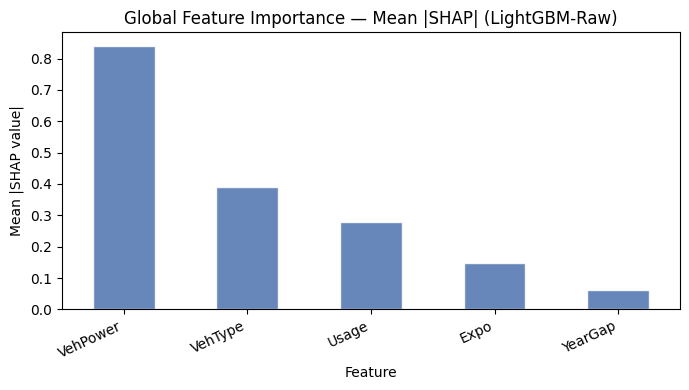

[CHECK 6] Saved: data/shap/07_global_importance.png

[CHECK 7] Generating SHAP beeswarm plot...


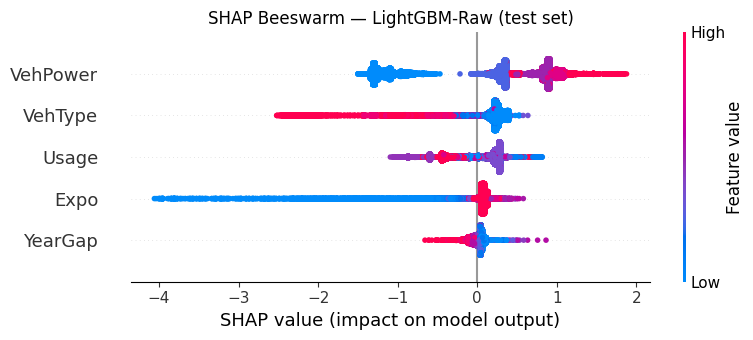

[CHECK 7] Saved: data/shap/07_beeswarm.png

[CHECK 8] Risk grade distribution:
 risk_grade  n_policyholders  positive_rate  mean_prob  mean_shap_sum
    G1_Safe             2142       0.070962   0.109359      -1.680906
 G2_Caution             2142       0.155462   0.199254      -0.910749
    G3_Risk             2141       0.319010   0.420975       0.149081
G4_HighRisk             2142       0.507937   0.598721       0.916736
G5_Critical             2142       0.718954   0.731447       1.529245


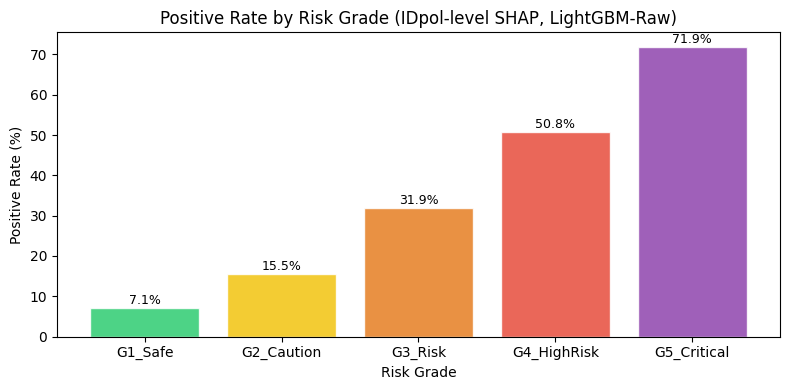

[CHECK 8] Saved: data/shap/07_risk_grades.png

[CHECK 9] Fairness audit (G1-G4) by observation cohort...

[CHECK 9] Fairness table (G1-G4) by observation cohort:
   cohort      n  G1_pos_rate  G2_TPR  G3_precision  G4_high_risk_%
1999-2000 2255.0       0.4550  0.7554        0.7203           42.22
2001-2002 2394.0       0.4202  0.7584        0.6658           42.44
2003-2004 2915.0       0.3479  0.7732        0.6087           39.25
2005-2006 3145.0       0.2385  0.7320        0.4191           37.27
  ⚠️  G1_pos_rate          gap = 0.2165
  ✅ G2_TPR               gap = 0.0412
  ⚠️  G3_precision         gap = 0.3012
  ⚠️  G4_high_risk_%       gap = 5.1700


C:\Users\miy\AppData\Local\Temp\ipykernel_42568\589206594.py:317: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fairness_table = df_fair.groupby("cohort", observed=True).apply(


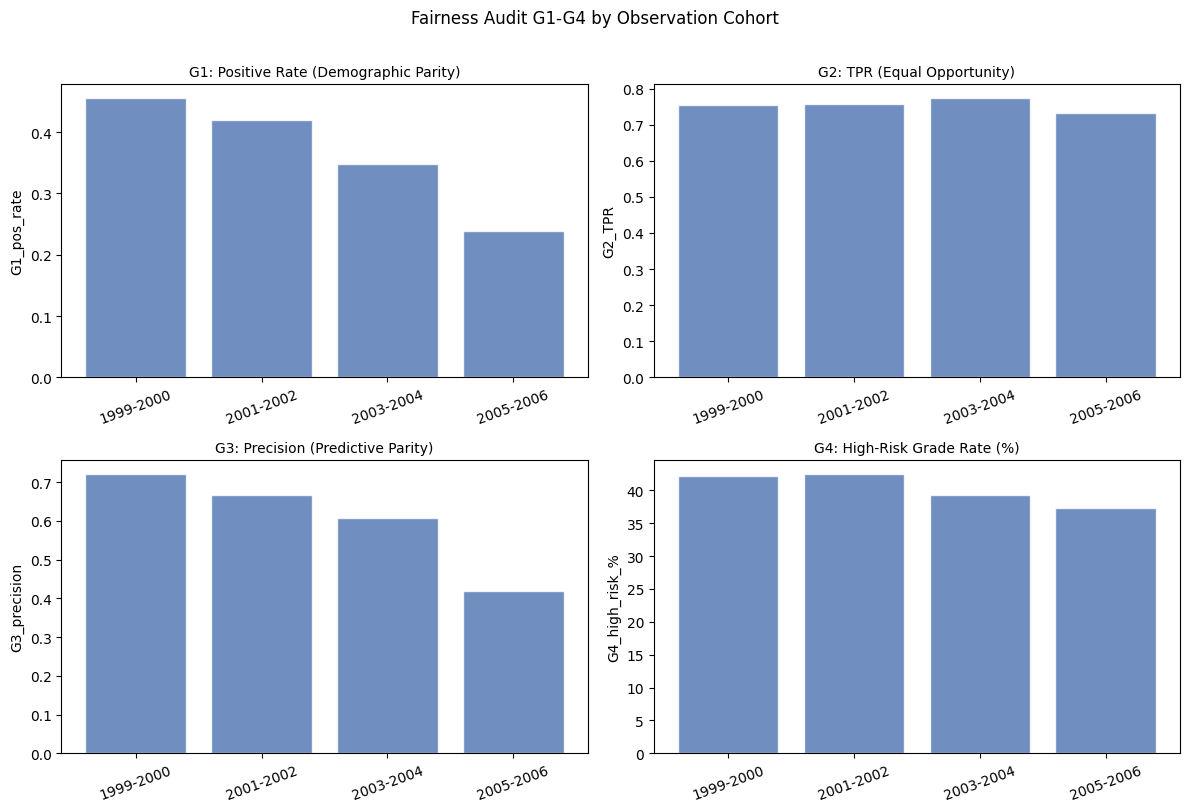

[CHECK 9] Saved: data/shap/07_fairness_g1g4.png

[CHECK 10] Saved files:
  data/shap/07_idpol_shap_summary.csv  (10,709 policyholders)
  data/shap/07_fairness_table.csv
  data/shap/07_grade_summary.csv
  data/shap/07_feature_importance.csv

===== SHAP Analysis Summary =====
Model           : LightGBM-Raw (AUC=0.7689)
Analysis unit   : IDpol-level (mean SHAP across years)
Test policyholders: 10,709

Top feature by mean |SHAP|:
  1. VehPower    : 0.8415
  2. VehType     : 0.3909
  3. Usage       : 0.2783
  4. Expo        : 0.1481
  5. YearGap     : 0.0619

Risk grade distribution:
  G1_Safe        : n=2,142, positive_rate=7.1%, mean_prob=0.109
  G2_Caution     : n=2,142, positive_rate=15.5%, mean_prob=0.199
  G3_Risk        : n=2,141, positive_rate=31.9%, mean_prob=0.421
  G4_HighRisk    : n=2,142, positive_rate=50.8%, mean_prob=0.599
  G5_Critical    : n=2,142, positive_rate=71.9%, mean_prob=0.731

Fairness G1-G4 audit: see data/shap/07_fairness_table.csv
LLM narrative input : data/shap

In [1]:
# ============================================================
# Notebook    : 07_shap_analysis.ipynb
# Description : SHAP-based feature importance analysis on
#               LightGBM-Raw model (best AUC=0.7687).
#               Analysis unit: IDpol-level average SHAP values
#               (each policyholder's mean contribution across
#               all observed years), enabling interpretation
#               at the individual risk profile level.
#
#               Outputs:
#               - Global feature importance (bar + beeswarm)
#               - IDpol-level SHAP summary (mean |SHAP| per person)
#               - Risk grade distribution by SHAP score
#               - Age-group fairness audit (Fairness G1-G4)
#               - Per-policyholder SHAP CSV for LLM narrative
# ============================================================


# ============================================================
# 0. Install dependencies (run once)
# ============================================================
# pip install shap lightgbm matplotlib pandas numpy scikit-learn


# ============================================================
# 1. Imports
# ============================================================
import os
import json
import pickle
import numpy as np
import pandas as pd
import shap
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import roc_auc_score

np.random.seed(42)
os.makedirs("data/shap", exist_ok=True)

print("[CHECK 1] Imports complete.")
print(f"[CHECK 1] SHAP version: {shap.__version__}")


# ============================================================
# 2. Rebuild LightGBM-Raw model and flat dataset
#    (LightGBM model object cannot be pickled with state from
#     notebook 06 easily, so we retrain with identical settings)
# ============================================================
df = pd.read_csv("data/fremotor_multi_history_features.csv")

with open("data/sequences/vocabs.json", "r", encoding="utf-8") as f:
    vocabs = json.load(f)

CAT_COLS     = ["Usage", "VehType", "VehPower"]
CONT_COLS    = ["Expo", "YearGap"]
FEATURE_COLS = ["Expo", "YearGap", "Usage", "VehType", "VehPower"]

from sklearn.preprocessing import MinMaxScaler
df_sorted = df.sort_values(["IDpol", "Year"]).reset_index(drop=True)
df_feat   = df_sorted.copy()
for col in CAT_COLS:
    df_feat[col] = df_feat[col].map(vocabs[col]).fillna(0).astype(int)
scaler = MinMaxScaler()
df_feat[CONT_COLS] = scaler.fit_transform(df_feat[CONT_COLS])

raw_lookup   = {(row["IDpol"], row["Year"]): row[FEATURE_COLS].values.astype(np.float32)
                for _, row in df_feat.iterrows()}
label_lookup = {(row["IDpol"], row["Year"]): row["Label"]
                for _, row in df.iterrows()}
idpol_lookup = {(row["IDpol"], row["Year"]): row["IDpol"]
                for _, row in df.iterrows()}
year_lookup  = {(row["IDpol"], row["Year"]): row["Year"]
                for _, row in df.iterrows()}
age_lookup   = {(row["IDpol"], row["Year"]): row["Year"]   # Year used as proxy
                for _, row in df.iterrows()}

with open("data/sequences/train_sequences.pkl", "rb") as f:
    train_seqs = pickle.load(f)
with open("data/sequences/val_sequences.pkl", "rb") as f:
    val_seqs = pickle.load(f)
with open("data/sequences/test_sequences.pkl", "rb") as f:
    test_seqs = pickle.load(f)

train_ids = [s["IDpol"] for s in train_seqs]
val_ids   = [s["IDpol"] for s in val_seqs]
test_ids  = [s["IDpol"] for s in test_seqs]

def build_flat(ids, raw_lookup, label_lookup,
               idpol_lookup, year_lookup):
    X, y, idpols, years = [], [], [], []
    id_set = set(ids)
    for (idpol, yr), feat in raw_lookup.items():
        if idpol not in id_set:
            continue
        key = (idpol, yr)
        X.append(feat)
        y.append(label_lookup.get(key, 0))
        idpols.append(idpol)
        years.append(yr)
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.int32),
            np.array(idpols), np.array(years))

X_tr,  y_tr,  idp_tr,  yr_tr  = build_flat(
    train_ids, raw_lookup, label_lookup, idpol_lookup, year_lookup)
X_val, y_val, idp_val, yr_val = build_flat(
    val_ids,   raw_lookup, label_lookup, idpol_lookup, year_lookup)
X_te,  y_te,  idp_te,  yr_te  = build_flat(
    test_ids,  raw_lookup, label_lookup, idpol_lookup, year_lookup)

print(f"\n[CHECK 2] Train rows: {len(y_tr):,} | "
      f"Val: {len(y_val):,} | Test: {len(y_te):,}")
print(f"[CHECK 2] Feature columns: {FEATURE_COLS}")


# ============================================================
# 3. Retrain LightGBM-Raw with identical settings as notebook 06
# ============================================================
LGB_PARAMS = {
    "objective"       : "binary",
    "metric"          : "auc",
    "n_estimators"    : 500,
    "learning_rate"   : 0.05,
    "num_leaves"      : 31,
    "scale_pos_weight": (1 - 0.1267) / 0.1267,
    "random_state"    : 42,
    "verbose"         : -1,
    "n_jobs"          : -1,
}

print(f"\n[CHECK 3] Retraining LightGBM-Raw...")
model = lgb.LGBMClassifier(**LGB_PARAMS)
model.fit(X_tr, y_tr,
          eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(50, verbose=False),
                     lgb.log_evaluation(100)])

probs_te = model.predict_proba(X_te)[:, 1]
auc_te   = roc_auc_score(y_te, probs_te)
print(f"[CHECK 3] Retrained LightGBM-Raw AUC: {auc_te:.4f} "
      f"(nb06 reference: 0.7687)")


# ============================================================
# 4. Compute SHAP values for the TEST set
#    - TreeExplainer: exact SHAP for tree-based models
#    - shap_values[:, :, 1] = contribution toward class 1 (risk)
# ============================================================
print(f"\n[CHECK 4] Computing SHAP values (TreeExplainer)...")
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_te)

# For binary LightGBM, shap_values may be a list [class0, class1]
# or a single array depending on SHAP version
if isinstance(shap_values, list):
    sv = shap_values[1]   # class 1 (risk = positive)
else:
    sv = shap_values      # newer SHAP returns single array for binary

print(f"[CHECK 4] SHAP values shape: {sv.shape}")
print(f"[CHECK 4] Expected: ({len(X_te)}, {len(FEATURE_COLS)})")


# ============================================================
# 5. Build IDpol-level SHAP summary
#    - For each policyholder in the test set, average the
#      SHAP values across all observed years
#    - This gives a per-person risk profile contribution
# ============================================================
df_shap = pd.DataFrame(sv, columns=FEATURE_COLS)
df_shap["IDpol"] = idp_te
df_shap["Year"]  = yr_te
df_shap["Label"] = y_te
df_shap["Prob"]  = probs_te

# Mean SHAP per IDpol (average across all years of that person)
idpol_shap = df_shap.groupby("IDpol")[FEATURE_COLS].mean().reset_index()
idpol_shap["mean_risk_shap"] = idpol_shap[FEATURE_COLS].sum(axis=1)
idpol_shap["Label"]          = df_shap.groupby("IDpol")["Label"].max().values
idpol_shap["Prob"]           = df_shap.groupby("IDpol")["Prob"].mean().values
idpol_shap["n_years"]        = df_shap.groupby("IDpol")["Year"].count().values
idpol_shap["year_min"]       = df_shap.groupby("IDpol")["Year"].min().values
idpol_shap["year_max"]       = df_shap.groupby("IDpol")["Year"].max().values

print(f"\n[CHECK 5] IDpol-level SHAP summary shape: {idpol_shap.shape}")
print(f"[CHECK 5] Columns: {list(idpol_shap.columns)}")
print(idpol_shap.head(3))


# ============================================================
# 6. Global feature importance — mean |SHAP| across all test rows
# ============================================================
mean_abs_shap = np.abs(sv).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=FEATURE_COLS).sort_values(ascending=False)

print(f"\n[CHECK 6] Global mean |SHAP| per feature:")
for feat, val in feat_imp.items():
    print(f"  {feat:12s}: {val:.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
feat_imp.plot(kind="bar", ax=ax, color="#4C72B0", alpha=0.85,
              edgecolor="white")
ax.set_title("Global Feature Importance — Mean |SHAP| (LightGBM-Raw)")
ax.set_ylabel("Mean |SHAP value|")
ax.set_xlabel("Feature")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("data/shap/07_global_importance.png", dpi=150)
plt.show()
print("[CHECK 6] Saved: data/shap/07_global_importance.png")


# ============================================================
# 7. SHAP beeswarm plot — distribution of SHAP values per feature
# ============================================================
print(f"\n[CHECK 7] Generating SHAP beeswarm plot...")
plt.figure(figsize=(8, 5))
shap.summary_plot(sv, X_te,
                  feature_names=FEATURE_COLS,
                  show=False, max_display=5)
plt.title("SHAP Beeswarm — LightGBM-Raw (test set)")
plt.tight_layout()
plt.savefig("data/shap/07_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("[CHECK 7] Saved: data/shap/07_beeswarm.png")


# ============================================================
# 8. Risk grade assignment (5-level) based on IDpol SHAP score
#    - Grade based on mean_risk_shap (sum of mean SHAP per person)
#    - G1=Safe, G2=Caution, G3=Risk, G4=High-Risk, G5=Critical
#    - Quintile-based: each grade has ~20% of test policyholders
# ============================================================
idpol_shap["risk_grade"] = pd.qcut(
    idpol_shap["mean_risk_shap"],
    q=5,
    labels=["G1_Safe", "G2_Caution", "G3_Risk",
            "G4_HighRisk", "G5_Critical"]
)

grade_summary = idpol_shap.groupby("risk_grade", observed=True).agg(
    n_policyholders = ("IDpol", "count"),
    positive_rate   = ("Label", "mean"),
    mean_prob       = ("Prob", "mean"),
    mean_shap_sum   = ("mean_risk_shap", "mean"),
).reset_index()

print(f"\n[CHECK 8] Risk grade distribution:")
print(grade_summary.to_string(index=False))

# Grade distribution bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors_grade = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]
bars = ax.bar(grade_summary["risk_grade"],
              grade_summary["positive_rate"] * 100,
              color=colors_grade, alpha=0.85, edgecolor="white")
ax.set_title("Positive Rate by Risk Grade (IDpol-level SHAP, LightGBM-Raw)")
ax.set_ylabel("Positive Rate (%)")
ax.set_xlabel("Risk Grade")
for bar, val in zip(bars, grade_summary["positive_rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{val*100:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("data/shap/07_risk_grades.png", dpi=150)
plt.show()
print("[CHECK 8] Saved: data/shap/07_risk_grades.png")


# ============================================================
# 9. Fairness audit — G1~G4 framework
#    Year is used as a proxy for observation period.
#    We group policyholders by first observed year to approximate
#    cohort-based fairness (proxy for age group since actual age
#    is not available in this dataset — noted as limitation).
#
#    G1: Demographic parity  — positive rate diff across groups
#    G2: Equal opportunity   — TPR diff across groups
#    G3: Predictive parity   — precision diff across groups
#    G4: Grade distribution  — % in high-risk grades per group
# ============================================================
print(f"\n[CHECK 9] Fairness audit (G1-G4) by observation cohort...")

# Assign cohort based on first observed year (5 groups)
idpol_shap["cohort"] = pd.cut(
    idpol_shap["year_min"],
    bins=[1998, 2000, 2002, 2004, 2006, 2008],
    labels=["1999-2000", "2001-2002", "2003-2004",
            "2005-2006", "2007-2008"]
)

# Merge grade info back
df_fair = idpol_shap[["IDpol", "Label", "Prob",
                        "risk_grade", "cohort"]].copy()
df_fair["pred_label"] = (df_fair["Prob"] >= 0.5).astype(int)
df_fair["high_risk"]  = df_fair["risk_grade"].isin(
    ["G4_HighRisk", "G5_Critical"]).astype(int)

def fairness_metrics(group):
    pos_rate  = group["Label"].mean()
    tpr       = (group.loc[group["Label"]==1, "pred_label"].mean()
                 if group["Label"].sum() > 0 else np.nan)
    precision = (group.loc[group["pred_label"]==1, "Label"].mean()
                 if group["pred_label"].sum() > 0 else np.nan)
    hr_rate   = group["high_risk"].mean()
    return pd.Series({
        "n"             : len(group),
        "G1_pos_rate"   : round(pos_rate, 4),
        "G2_TPR"        : round(tpr, 4) if not np.isnan(tpr) else np.nan,
        "G3_precision"  : round(precision, 4) if not np.isnan(precision) else np.nan,
        "G4_high_risk_%": round(hr_rate * 100, 2),
    })

fairness_table = df_fair.groupby("cohort", observed=True).apply(
    fairness_metrics).reset_index()

print(f"\n[CHECK 9] Fairness table (G1-G4) by observation cohort:")
print(fairness_table.to_string(index=False))

# Fairness gap (max - min across cohorts)
for metric in ["G1_pos_rate", "G2_TPR", "G3_precision", "G4_high_risk_%"]:
    vals = fairness_table[metric].dropna()
    gap  = vals.max() - vals.min()
    flag = "⚠️ " if gap > 0.05 else "✅"
    print(f"  {flag} {metric:20s} gap = {gap:.4f}")

# Fairness plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = ["G1_pos_rate", "G2_TPR", "G3_precision", "G4_high_risk_%"]
titles  = ["G1: Positive Rate (Demographic Parity)",
           "G2: TPR (Equal Opportunity)",
           "G3: Precision (Predictive Parity)",
           "G4: High-Risk Grade Rate (%)"]
for ax, metric, title in zip(axes.flat, metrics, titles):
    vals = fairness_table[metric].fillna(0)
    ax.bar(fairness_table["cohort"], vals,
           color="#4C72B0", alpha=0.8, edgecolor="white")
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("Fairness Audit G1-G4 by Observation Cohort",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("data/shap/07_fairness_g1g4.png", dpi=150, bbox_inches="tight")
plt.show()
print("[CHECK 9] Saved: data/shap/07_fairness_g1g4.png")


# ============================================================
# 10. Save IDpol-level SHAP table for LLM narrative (notebook 08)
#     Each row = one policyholder, with mean SHAP per feature,
#     risk grade, and observation metadata.
# ============================================================
idpol_shap.to_csv("data/shap/07_idpol_shap_summary.csv",
                  index=False, encoding="utf-8-sig")
fairness_table.to_csv("data/shap/07_fairness_table.csv",
                      index=False, encoding="utf-8-sig")
grade_summary.to_csv("data/shap/07_grade_summary.csv",
                     index=False, encoding="utf-8-sig")
feat_imp.to_csv("data/shap/07_feature_importance.csv",
                header=["mean_abs_shap"], encoding="utf-8-sig")

print(f"\n[CHECK 10] Saved files:")
print(f"  data/shap/07_idpol_shap_summary.csv  "
      f"({len(idpol_shap):,} policyholders)")
print(f"  data/shap/07_fairness_table.csv")
print(f"  data/shap/07_grade_summary.csv")
print(f"  data/shap/07_feature_importance.csv")


# ============================================================
# 11. Summary
# ============================================================
print(f"\n===== SHAP Analysis Summary =====")
print(f"Model           : LightGBM-Raw (AUC={auc_te:.4f})")
print(f"Analysis unit   : IDpol-level (mean SHAP across years)")
print(f"Test policyholders: {len(idpol_shap):,}")
print(f"\nTop feature by mean |SHAP|:")
for i, (feat, val) in enumerate(feat_imp.items()):
    print(f"  {i+1}. {feat:12s}: {val:.4f}")
print(f"\nRisk grade distribution:")
for _, row in grade_summary.iterrows():
    print(f"  {row['risk_grade']:15s}: "
          f"n={int(row['n_policyholders']):,}, "
          f"positive_rate={row['positive_rate']*100:.1f}%, "
          f"mean_prob={row['mean_prob']:.3f}")
print(f"\nFairness G1-G4 audit: see data/shap/07_fairness_table.csv")
print(f"LLM narrative input : data/shap/07_idpol_shap_summary.csv")
print(f"=================================")